# Energy Batch Trader — Strategy Research

EOD energy pipeline trading **USO** (front-month WTI futures ETF) and **XLE**
(energy equities). The question that started this: *does the strategy beat
buy-and-hold?* This notebook reproduces the findings end-to-end:

1. **A data bug came first.** USO's 2020 1-for-8 reverse split, on *raw* Alpaca
   bars, was a fake +745% day that corrupted every backtest. Fix: adjusted bars.
2. **On clean data, SMA trend-following beats B&H on USO** — by dodging USO's
   contango drawdowns.
3. **The energy-specific carry / roll-yield signal does *not* add value** over the
   SMA baseline — neither standalone nor as a regime filter.
4. **Volatility targeting cut drawdown on the 10-year window** (§4)…
5. **…but the 20-year reality check (§5) reframes everything.** Alpaca's history
   starts in 2016; going back to 2006 adds 2008 and the 2014–15 oil crash. Over
   20 years nothing energy-based beat SPY, USO lost 98% peak-to-trough, and the
   strategy that holds up is a slow 50/200 trend filter on an XLE-heavy mix —
   which is what runs live now.

Everything below reuses the package modules, so the notebook can't disagree with
`python -m energy_trader --backtest`.

In [1]:
# Setup — find project root so this runs from anywhere (notebooks/ or repo root)
import os, sys
from pathlib import Path

root = Path.cwd()
while not (root / "energy_trader").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))
os.chdir(root)                       # .env + plots/ resolve from the repo root
from dotenv import load_dotenv
load_dotenv(root / ".env")           # load API keys regardless of launch dir

import dataclasses, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from energy_trader.config import get_settings
from energy_trader.data import extract_market_data
from energy_trader.eia import fetch_wti_spot
from energy_trader.backtest import backtest_symbol, compare_uso_carry, format_comparison
from energy_trader import plots

print("project root:", root.name)   # name only — no local paths in a public repo

project root: energy-batch-trader


In [2]:
# Load 10y of split/dividend-adjusted data for USO + XLE, plus WTI spot (EIA)
YEARS = 10
base = dataclasses.replace(get_settings(), assets=["USO", "XLE"],
                           lookback_days=int(YEARS * 252))
data = extract_market_data(base)
wti = fetch_wti_spot(base, length=base.lookback_days * 2 + 60)
{k: (v.index.min().date(), v.index.max().date(), len(v)) for k, v in data.items()}

{'USO': (datetime.date(2016, 1, 4), datetime.date(2026, 10, 2), 2703),
 'XLE': (datetime.date(2016, 1, 4), datetime.date(2026, 10, 2), 2703)}

## 1. Data-quality first: the reverse-split trap

USO did a **1-for-8 reverse split on 2020-04-29**. On *raw* bars the price jumps
\$2.13 → \$18.00 overnight — a fake +745% day that inflates buy-and-hold ~8× and
poisons every signal. The fix is one parameter: request **split+dividend-adjusted**
bars (`Adjustment.ALL`, now the default in `data.py`). Here's the side-by-side.

In [3]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from alpaca.data.enums import Adjustment

client = StockHistoricalDataClient(base.alpaca_api_key, base.alpaca_secret_key)

def _close(adj):
    req = StockBarsRequest(symbol_or_symbols="USO", timeframe=TimeFrame.Day,
                           start=pd.Timestamp("2020-04-22"),
                           end=pd.Timestamp("2020-05-02"), adjustment=adj)
    s = client.get_stock_bars(req).df.loc["USO"]["close"]
    s.index = pd.DatetimeIndex(s.index).normalize().date
    return s

cmp = pd.DataFrame({"raw": _close(Adjustment.RAW), "adjusted": _close(Adjustment.ALL)})
print("Largest raw 1-day 'return' in this window: "
      f"{cmp['raw'].pct_change().max():+.0%}  (fake — the 1:8 reverse split on 2020-04-29). "
      "Adjusted bars stay continuous.")
cmp.round(2)

Largest raw 1-day 'return' in this window: +745%  (fake — the 1:8 reverse split on 2020-04-29). Adjusted bars stay continuous.


,raw,adjusted
2020-04-22,2.50,20.00
2020-04-23,2.64,21.12
2020-04-24,2.57,20.56
2020-04-27,2.19,17.52
2020-04-28,2.13,17.04
2020-04-29,18.00,18.00
2020-04-30,19.17,19.17
2020-05-01,18.72,18.72


## 2. Does SMA beat buy-and-hold?

Run the live SMA crossover over history (same `crossover_series` the pipeline
trades) and plot the equity curve + drawdown the backtest already computes.

SMA(10/50) ret  +94.3%  CAGR  +6.4%  Sharpe  0.38  MaxDD -48.8%  trades  39  win  49%  |  B&H  +67.8%


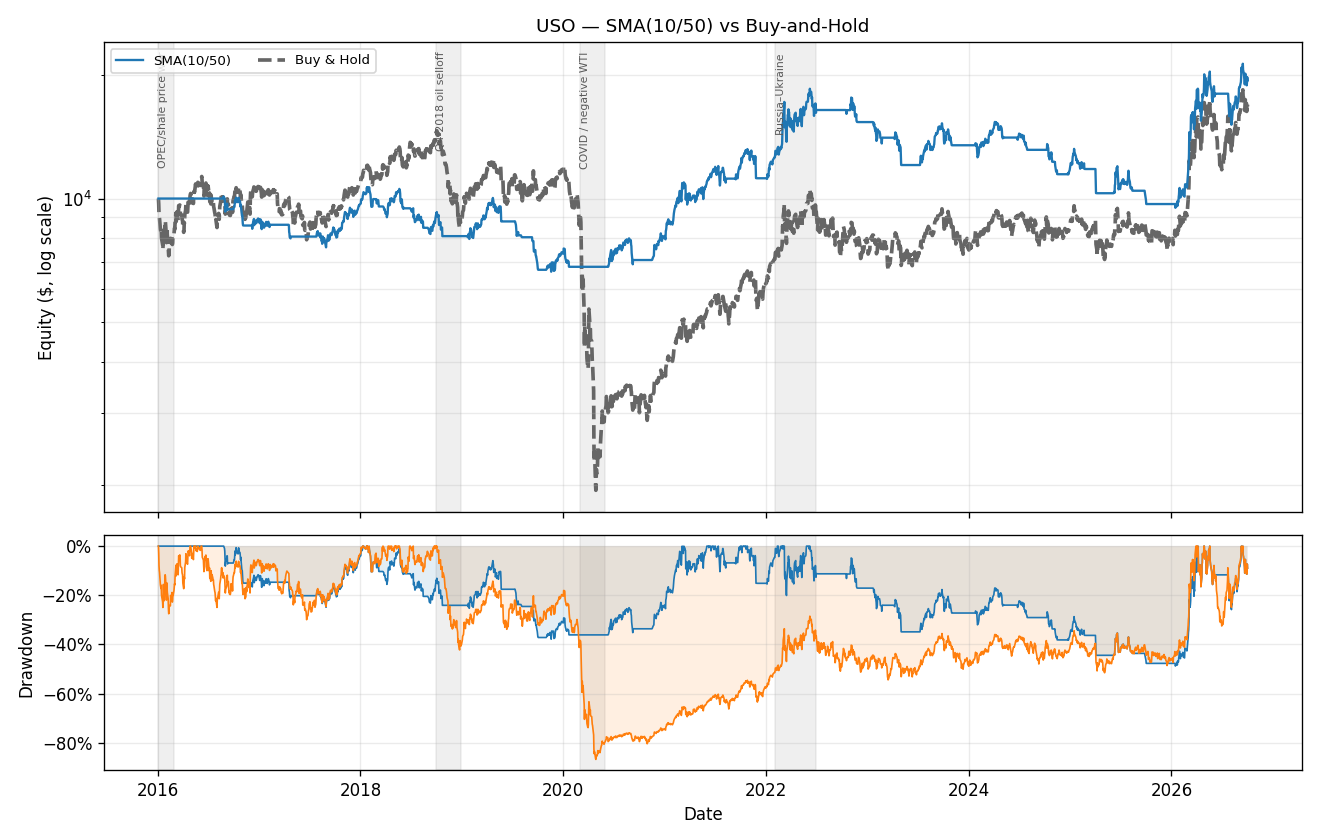

In [4]:
sma = dataclasses.replace(base, fast_window=10, slow_window=50)   # 10/50 is best on USO
res = backtest_symbol("SMA(10/50)", data["USO"]["Close"], sma)
print(res.describe())

curves = plots.equity_curves([res], bench_close=data["USO"]["Close"])
p = plots.plot_equity_drawdown(curves, path="plots/nb_sma_uso.png",
                               title="USO — SMA(10/50) vs Buy-and-Hold")
display(Image(str(p)))

**SMA beats B&H on USO** (+94% vs +68% on the 10y window) at roughly half the drawdown — it works
by sitting out USO's worst contango bleeds. Is that robust or an overfit window?
The heatmap below sweeps `(fast, slow)`: most of the grid is green (beats the
+38% B&H), so the edge isn't a single lucky cell.

In [5]:
fasts, slows = [5, 10, 20, 30], [20, 50, 100, 150, 200]
M = np.full((len(fasts), len(slows)), np.nan)
for i, f in enumerate(fasts):
    for j, s in enumerate(slows):
        if f < s:
            r = backtest_symbol("x", data["USO"]["Close"],
                                dataclasses.replace(base, fast_window=f, slow_window=s))
            M[i, j] = r.total_return

fig, ax = plt.subplots(figsize=(7.5, 4))
im = ax.imshow(M, cmap="RdYlGn", aspect="auto",
               vmin=-abs(np.nanmax(M)), vmax=abs(np.nanmax(M)))
ax.set_xticks(range(len(slows))); ax.set_xticklabels(slows)
ax.set_yticks(range(len(fasts))); ax.set_yticklabels(fasts)
ax.set_xlabel("slow window"); ax.set_ylabel("fast window")
ax.set_title(f"USO SMA total return  (B&H = {res.bh_total_return:+.0%})")
for i in range(len(fasts)):
    for j in range(len(slows)):
        if not np.isnan(M[i, j]):
            ax.text(j, i, f"{M[i, j]:+.0%}", ha="center", va="center", fontsize=8)
fig.colorbar(im, label="total return"); plt.tight_layout(); plt.show()

## 3. Carry / roll-yield — does the energy-specific signal help?

USO's return = WTI *spot* return **+ roll yield** (positive in backwardation,
negative in contango). The regime chart below — trailing 63d (USO − WTI) return —
shows the reality: 2016–17 deep contango, the 2020 blowout, then a mostly *mild,
mixed* regime. The genuinely useful "deep contango to avoid" signal is rare.

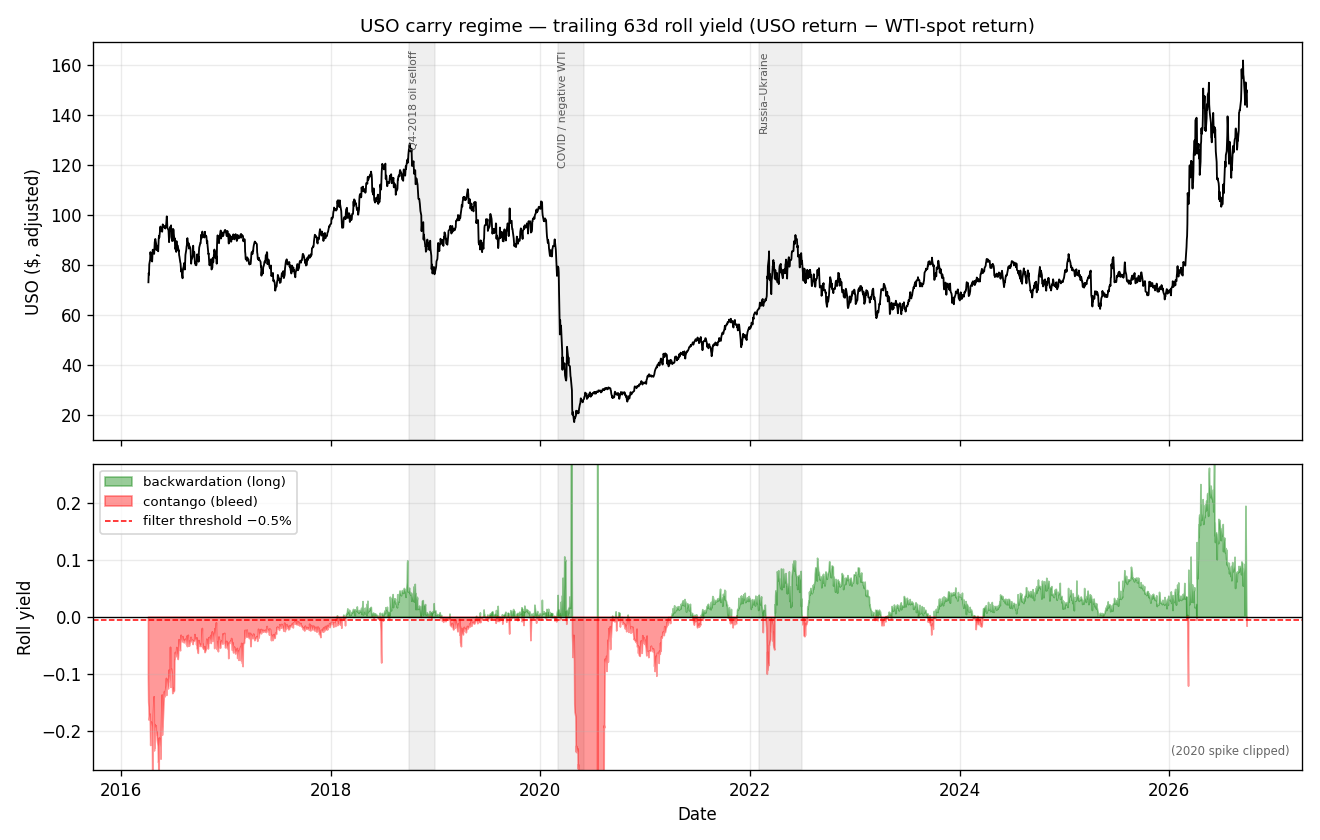

In [6]:
p = plots.plot_carry_regime(data["USO"]["Close"], wti, base.carry_window,
                            base.carry_band, path="plots/nb_carry_regime.png")
display(Image(str(p)))

Now the test the project is built around: **SMA baseline vs SMA gated by the
carry regime vs buy-and-hold**, all on one window so the B&H column is the shared
bar to clear.

USO: SMA vs SMA+carry vs Buy-and-Hold (carry filter)
----------------------------------------------------
SMA(10/50) ret  +92.3%  CAGR  +6.3%  Sharpe  0.37  MaxDD -48.5%  trades  37  win  49%  |  B&H  +63.2%
SMA+carry ret  +79.3%  CAGR  +5.6%  Sharpe  0.37  MaxDD -45.7%  trades  76  win  51%  |  B&H  +63.2%
carry-only ret   -0.5%  CAGR  -0.0%  Sharpe  0.16  MaxDD -80.8%  trades  45  win  62%  |  B&H  +63.2%
(B&H column = USO buy-and-hold over the same window — the bar to beat.)


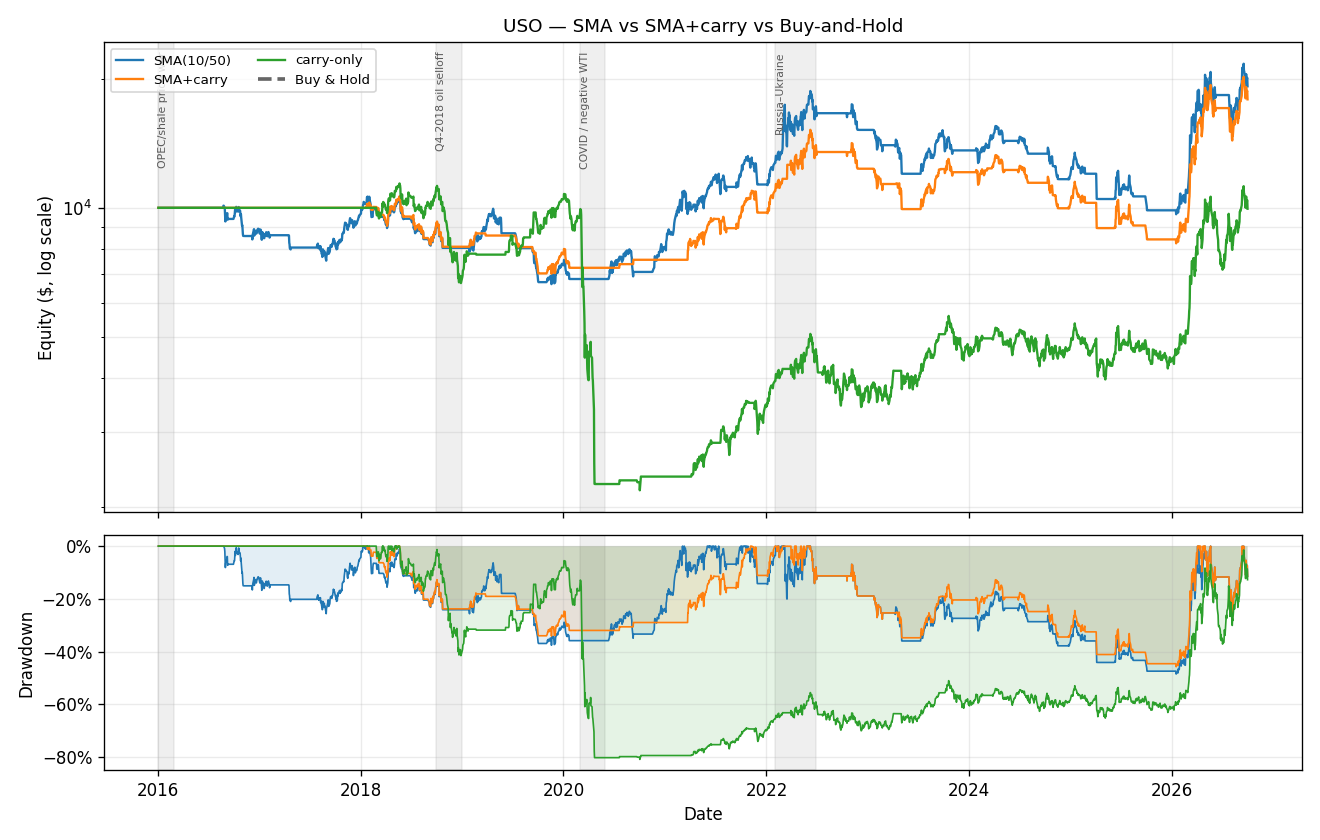

In [7]:
results = compare_uso_carry(data["USO"]["Close"], wti, sma)   # SMA(10/50) baseline
print(format_comparison(results, "USO: SMA vs SMA+carry vs Buy-and-Hold (carry filter)"))

curves = plots.equity_curves(results, bench_close=data["USO"]["Close"])
p = plots.plot_equity_drawdown(curves, path="plots/nb_carry_eq.png",
                               title="USO — SMA vs SMA+carry vs Buy-and-Hold")
display(Image(str(p)))

## 4. Taming the drawdown: volatility targeting

Carry didn't help, but the open problem was always USO's ~−50% drawdown. The
textbook fix (Kaufman, *Trading Systems and Methods*, ch.23) is **volatility
targeting**: the SMA decides *direction*, but the position is *sized* to constant
risk — `weight = target_vol / realized_vol`, capped at 1.0 (long-only cash). When
vol spikes in a shock, exposure shrinks **before** the worst of the drawdown.

USO: SMA vs SMA+vol-target vs Buy-and-Hold
------------------------------------------
USO SMA   ret  +88.5%  CAGR  +6.1%  Sharpe  0.36  MaxDD -67.4%  trades  88  win  42%  |  B&H  +67.8%
USO +voltgt20% ret  +78.7%  CAGR  +5.6%  Sharpe  0.42  MaxDD -43.6%  trades  88  win  42%  |  B&H  +67.8%
(B&H column = USO buy-and-hold over the same window — the bar to beat.)


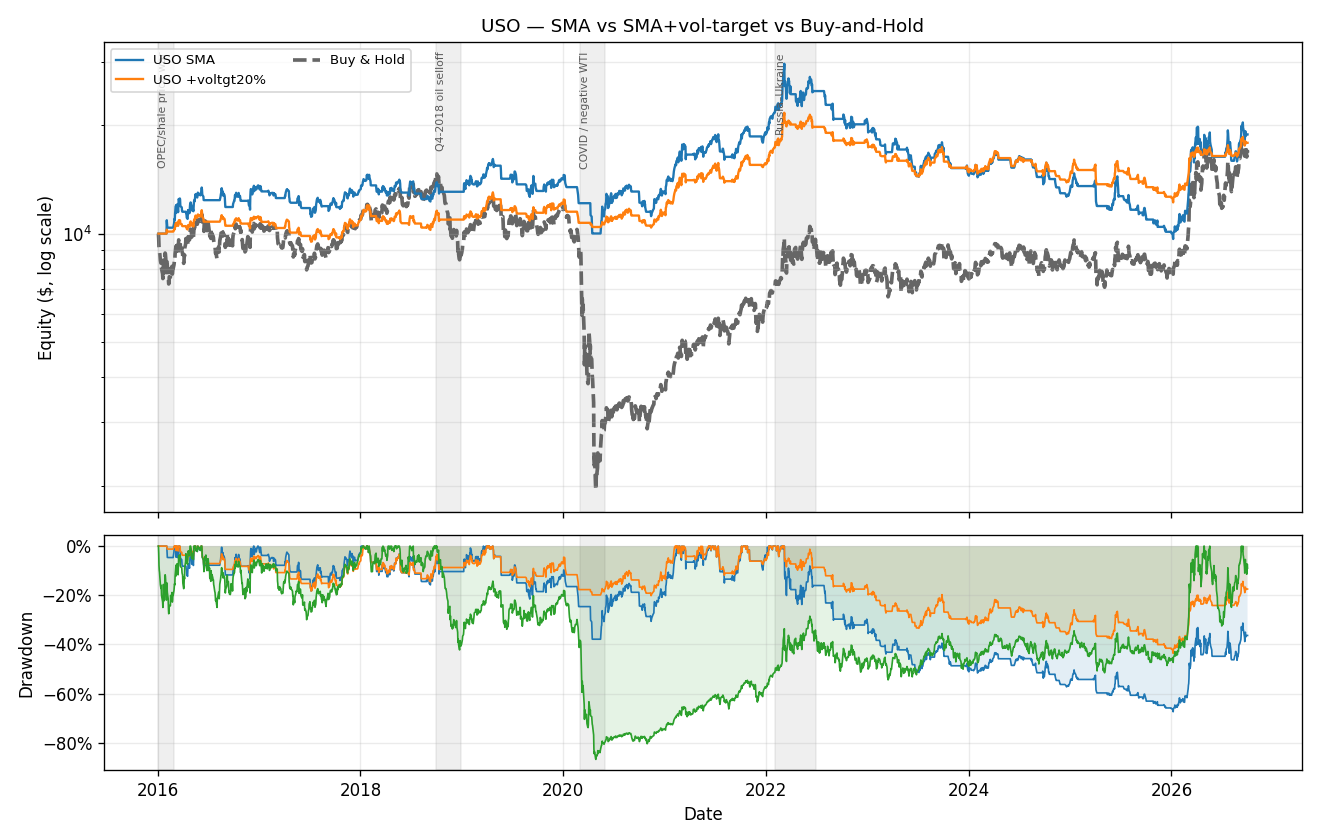

In [8]:
from energy_trader.backtest import compare_vol_target

vt = compare_vol_target("USO", data["USO"]["Close"], base)   # base = default SMA(5/20)
print(format_comparison(vt, "USO: SMA vs SMA+vol-target vs Buy-and-Hold"))

curves = plots.equity_curves(vt, bench_close=data["USO"]["Close"])
p = plots.plot_equity_drawdown(curves, path="plots/nb_voltgt_uso.png",
                               title="USO — SMA vs SMA+vol-target vs Buy-and-Hold")
display(Image(str(p)))

On the default **SMA(5/20)** the overlay is a strict win — return holds,
Sharpe rises (~0.31 → 0.38), and max drawdown drops from ~−67% to ~−44%. (On the
smoother 10/50 it's more of a pure trade: similar drawdown cut for some give-up in
raw return.) The mechanism chart shows *why* — realized vol (top) spikes through
the shock bands, so the position (bottom) is throttled toward zero exactly then.

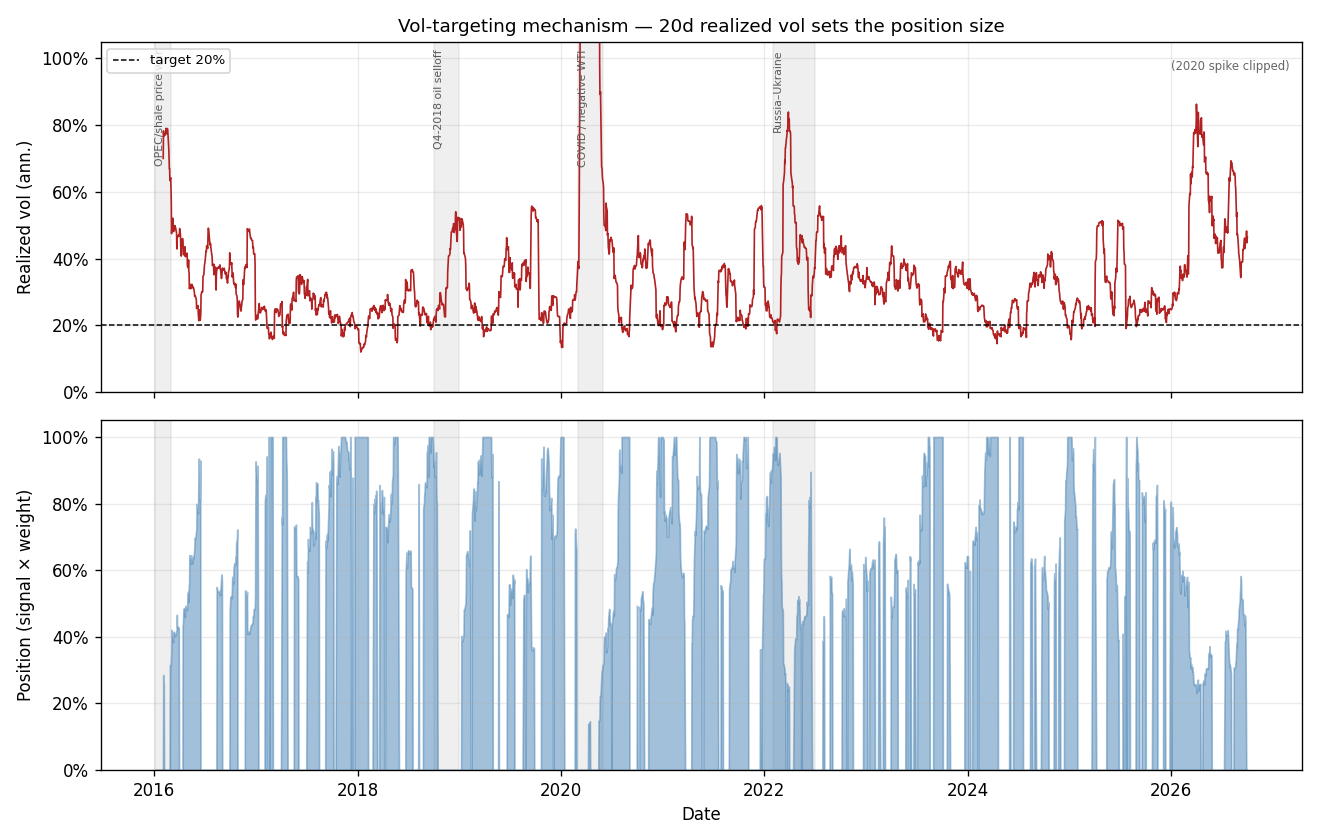

In [9]:
p = plots.plot_vol_target(data["USO"]["Close"], base, path="plots/nb_voltgt_mech.png")
display(Image(str(p)))

## 5. The 20-year reality check

Sections 1–4 use Alpaca bars, which start in **2016**. That window skips the two
regimes that matter most for energy — **2008** and the **2014–15 oil crash** — and
it flattered every result. (The first live mix, 50% XLE / 30% USO / 20% cash,
looked like **+9%/yr** from 2016. From 2006 it's **+3.6%/yr**.)

`energy_trader/longrun.py` pulls split/dividend-adjusted closes back to 2006
(Yahoo, research-only) and replays the **live rules** at the account level:
signal on close *t*, trade at close *t+1*, holdings drift between trades, 0.10%
cost per $ traded, idle cash earns the 13-week T-bill. Sharpe is *excess* of
T-bills, so a mostly-cash strategy can't look good just by sitting in cash.

In [10]:
from energy_trader import longrun as lr

px, tbill = lr.load_history()          # SPY, XLE, USO + ^IRX, 2006-04 → today
table, curves = lr.compare(px, tbill)
print(f"{px.index[0].date()} → {px.index[-1].date()}")
table.style.format({"CAGR": "{:+.1%}", "Vol": "{:.1%}", "Sharpe": "{:.2f}",
                    "MaxDD": "{:+.0%}", "Calmar": "{:.2f}", "Exposure": "{:.0%}",
                    "Turnover": "{:.1f}x"})

2006-04-10 → 2026-10-02


,CAGR,Vol,Sharpe,MaxDD,Calmar,Exposure,Turnover
strategy,,,,,,,
SPY buy & hold,+11.2%,19.3%,0.56,-55%,0.20,100%,0.0x
XLE buy & hold,+7.1%,30.0%,0.33,-71%,0.10,100%,0.0x
USO buy & hold,-6.2%,37.5%,-0.03,-98%,-0.06,101%,0.1x
50/30/20 quarterly (first live mix),+3.6%,23.2%,0.20,-70%,0.05,80%,0.2x
"70/10/20 quarterly, no filter",+5.7%,23.1%,0.28,-62%,0.09,80%,0.1x
70/10/20 + SMA50/200 filter (LIVE),+6.6%,15.0%,0.39,-27%,0.25,49%,1.2x
"SMA5/20 as first configured (10%/sym, voltgt)",+2.0%,2.4%,0.14,-6%,0.36,8%,2.5x
"SMA5/20 on 50/30, voltgt",+2.5%,9.6%,0.14,-26%,0.10,34%,10.1x
SMA50/200 on 50/30,+5.8%,15.0%,0.34,-32%,0.18,47%,1.3x


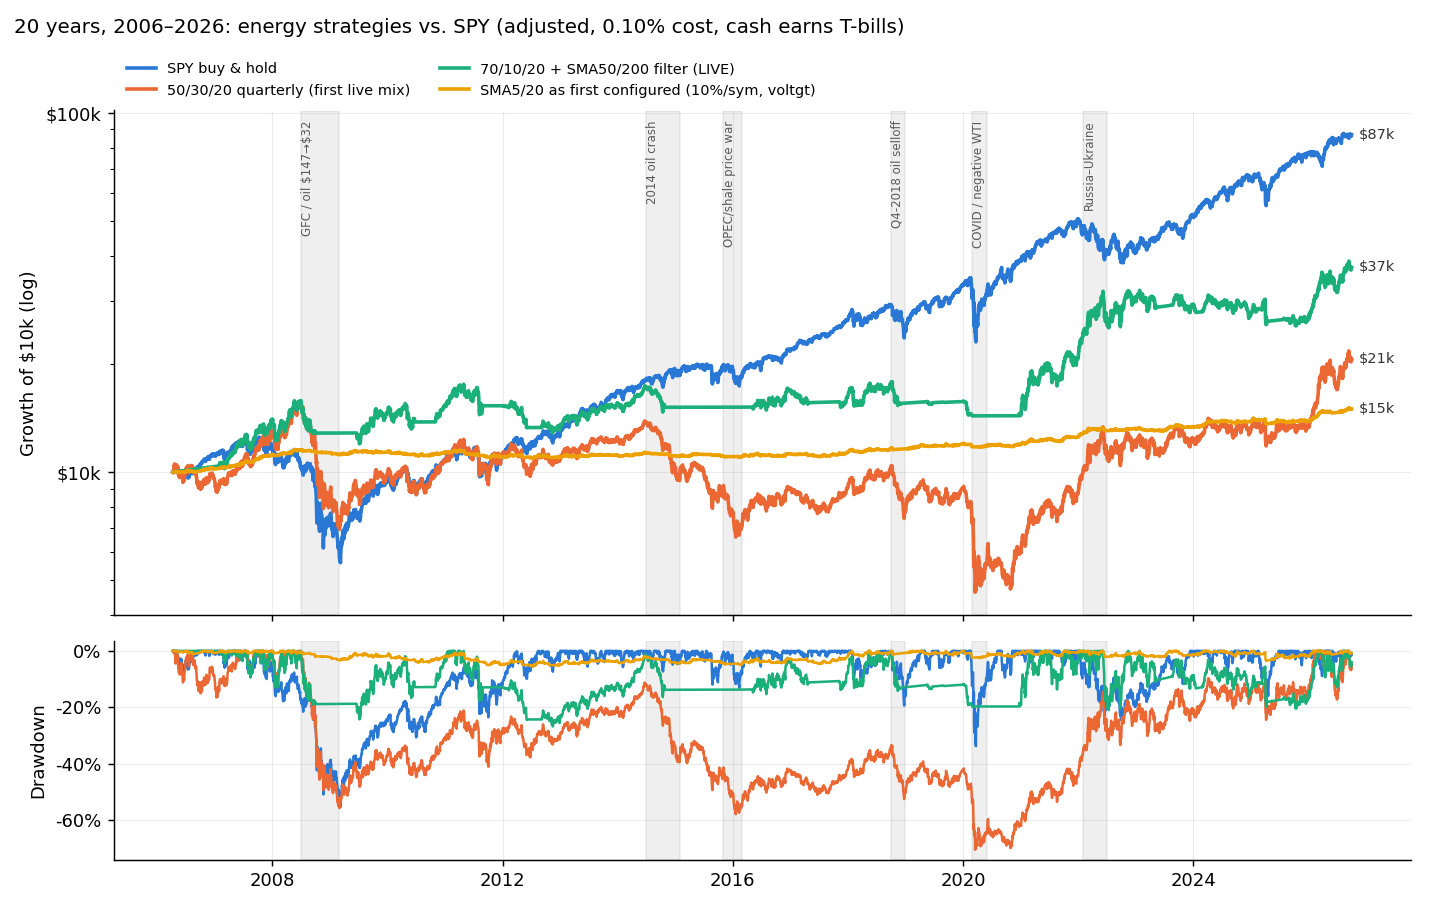

In [11]:
names = ["SPY buy & hold", "50/30/20 quarterly (first live mix)",
         "70/10/20 + SMA50/200 filter (LIVE)", "SMA5/20 as first configured (10%/sym, voltgt)"]
p = plots.plot_longrun(curves, names, path="plots/longrun_20y.png",
                       title="20 years, 2006–2026: energy strategies vs. SPY "
                             "(adjusted, 0.10% cost, cash earns T-bills)")
display(Image(str(p)))

**What the table says**

- **SPY buy-and-hold wins on return** (+11%/yr). Nothing energy-based beat it —
  as expected for a slow signal on a sector, and it's still the right baseline.
- **USO is the structural drag**: −6%/yr, −98% peak-to-trough. It holds front-month
  futures and pays roll yield in contango (§3). Cutting it from 30% → 10% alone
  lifts the static mix from +3.6% → +5.7%/yr.
- **The SMA as first configured (5/20, 10% per symbol, vol-targeted) was a T-bill
  account**: 8% average exposure, +2.0%/yr vs ~1.7% T-bills. And 5/20 is a *fast*
  signal — 10x+ turnover/yr on a real budget.
- **The slow 50/200 filter is what holds up**: on the 70/10/20 mix it's +6.6%/yr
  with a −27% max drawdown (vs −62% unfiltered), roughly one round trip a year.

Is that robust, or one lucky period? Split it by regime:

In [12]:
lr.subperiods(curves).style.format("{:+.0%}")

,2006–10 (GFC),2011–15 (oil crash),2016–19,"2020 (COVID, −$37 WTI)",2021–22 (energy bull),2023–26
SPY buy & hold,+8%,+78%,+73%,+17%,+7%,+112%
XLE buy & hold,+31%,-3%,+16%,-33%,+152%,+68%
USO buy & hold,-43%,-72%,+17%,-68%,+119%,+119%
50/30/20 quarterly (first live mix),+8%,-29%,+16%,-34%,+106%,+74%
"70/10/20 quarterly, no filter",+21%,-11%,+15%,-26%,+112%,+63%
70/10/20 + SMA50/200 filter (LIVE),+54%,-2%,+4%,-8%,+112%,+25%
"SMA5/20 as first configured (10%/sym, voltgt)",+14%,-3%,+9%,-0%,+11%,+14%
"SMA5/20 on 50/30, voltgt",+25%,-13%,+17%,-3%,+40%,-1%
SMA50/200 on 50/30,+51%,-8%,-5%,-12%,+111%,+30%
SPY + SMA50/200 filter,+40%,+42%,+46%,-9%,+23%,+70%


The filter earns its keep in the crashes (2008: +54% vs +21% unfiltered;
2020: −8% vs −26%) and **pays for it in choppy or V-shaped markets**: 2023–26 it
made +25% while XLE made +68%, because it sat out sharp rebounds. That trade-off
is the whole point of a slow trend filter: less pain, some missed upside.

Last check — selection bias. 50/200 is the best of many SMA settings, so judge
the **distribution** across settings, not the best cell:

In [13]:
sweep = lr.sma_sweep(px, tbill)   # 34 variants on the 50/30 budget
base = table.loc["50/30/20 quarterly (first live mix)"]
vt = sweep[sweep.voltgt].set_index(["fast", "slow"]).CAGR
raw = sweep[~sweep.voltgt].set_index(["fast", "slow"]).CAGR
print(f"{len(sweep)} variants | CAGR median {sweep.CAGR.median():+.1%} "
      f"(range {sweep.CAGR.min():+.1%} … {sweep.CAGR.max():+.1%})")
print(f"beat the static mix on CAGR: {(sweep.CAGR > base.CAGR).mean():.0%} | "
      f"shallower max drawdown: {(sweep.MaxDD > base.MaxDD).mean():.0%}")
print(f"vol-targeting lowered CAGR in {(vt < raw).mean():.0%} of fast/slow pairs")
sweep.sort_values("Calmar", ascending=False).head(5)

34 variants | CAGR median +3.1% (range +1.6% … +5.8%)
beat the static mix on CAGR: 26% | shallower max drawdown: 100%
vol-targeting lowered CAGR in 100% of fast/slow pairs


,fast,slow,voltgt,CAGR,Vol,Sharpe,MaxDD,Calmar,Exposure,Turnover
33,50,200,False,0.057894,0.149579,0.340308,-0.323811,0.178789,0.473257,1.259627
27,20,200,False,0.048227,0.145540,0.282553,-0.342799,0.140687,0.475804,1.794189
25,20,150,False,0.045635,0.143158,0.267563,-0.353054,0.129257,0.476517,2.194367
19,10,200,False,0.048548,0.144148,0.286018,-0.375930,0.129142,0.474090,2.384089
13,10,50,False,0.042660,0.143757,0.247200,-0.347889,0.122624,0.460896,5.484566


- A trend filter **cut drawdown in every variant**, but beat the static mix's
  return in only about a quarter of them. Expect drawdown control, not alpha.
- **Vol-targeting lowered return in every pair over 20 years.** The §4 "strict
  win" was a 10-year artifact. The live allocation doesn't use it.
- 50/200 is the best cell, so its real-world edge is probably smaller than shown.
  It was chosen because slow filters are the textbook default (Faber's 10-month /
  200-day rule), not because it topped this grid.

**What changed live (2026-10):** 70% XLE / 10% USO / 20% cash, a 50/200 trend
filter per symbol (exit on a down-cross, re-enter on an up-cross), quarterly
rebalance, deposits deployed buy-only (`allocation.py`).

## Conclusions

- **Always use split/dividend-adjusted bars.** The raw 2020 reverse split made
  every earlier backtest (and the roll-decay diagnostic) wrong.
- **SMA(10/50) beats buy-and-hold on USO** (+94% vs +68% on the 10y window, ~half the drawdown),
  robustly across windows — it dodges USO's contango drawdowns.
- **Carry / roll-yield does not beat the SMA baseline** — standalone it fails
  (−16%, −80% DD); as a filter it either over-vetoes good trends or becomes a
  near-no-op. It's a useful *regime diagnostic*, not a tradeable edge here.
- **Volatility targeting tamed the 10-year drawdown** (Kaufman ch.23; §4), but over
  **20 years it lowered return in every SMA pair** — a window artifact, now unused live.
- **Test on the longest history you can get.** 2016-onward data hid 2008 and the
  2014–15 crash; the first live mix went from "+9%/yr" to +3.6%/yr (−70% DD).
- **USO is a small sleeve, not a core holding** (−6%/yr over 20y, roll decay).
- **Nothing beat SPY.** The live setup (70/10/20 + slow 50/200 filter) is about
  surviving energy crashes (−27% max DD), not beating the index.
- **Risk gaps that remain:** the anomaly gate only catches EIA inventory shocks,
  not war/geopolitics (a planned layer), and it's live-only — backtests don't
  apply it. Vol-targeting is a *defense*; a geopolitical gate would be
  *detection*.